imports & config

In [48]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import networkx as nx
import osmnx as ox

from shapely.geometry import Point
from scipy import sparse
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

In [49]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'data' / 'raw').exists() and (p / 'data' / 'processed').exists():
            return p
    raise FileNotFoundError('Could not locate project root with data/raw and data/processed')

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEC_LAT, TEC_LON = 25.6516, -100.2895
PROJ_EPSG = 32614

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RAW_DIR =', RAW_DIR)

PROJECT_ROOT = C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location
RAW_DIR = C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\raw


In [50]:
manzanas_shp_path = RAW_DIR / 'INEGI_Manzanas_.shp'
manzanas_csv_path = RAW_DIR / 'INEGI_Manzanas_.csv'
oxxo_csv_path = RAW_DIR / 'INEGI_DENUE_25042025.csv'

manzanas_geom = gpd.read_file(manzanas_shp_path)[['geometry']].copy()
manzanas_geom = manzanas_geom.set_crs('EPSG:4326', allow_override=True)

# Centroids in projected CRS, then back to lat/lon for robust coordinates
centroids_wgs84 = manzanas_geom.to_crs(epsg=PROJ_EPSG).centroid.to_crs(epsg=4326)
manzanas_geom['centroide'] = centroids_wgs84
manzanas_geom['lat'] = manzanas_geom['centroide'].y
manzanas_geom['lon'] = manzanas_geom['centroide'].x

manzanas_csv = pd.read_csv(manzanas_csv_path, encoding='latin1').copy()
manzanas_csv = manzanas_csv.iloc[:len(manzanas_geom)].copy()
manzanas_csv['geometry_poly'] = manzanas_geom['geometry'].values
manzanas_csv['centroide'] = manzanas_geom['centroide'].values
manzanas_csv['lat'] = manzanas_geom['lat'].values
manzanas_csv['lon'] = manzanas_geom['lon'].values

manzanas_csv[['lat', 'lon']].head()

,lat,lon
0,25.642007,-100.209825
1,25.679448,-100.222937
2,25.662015,-100.227509
3,25.648454,-100.208694
4,25.678120,-100.400491


In [51]:
# Keep study area: 5 km around Tec
gdf_points = gpd.GeoDataFrame(
    manzanas_csv.copy(),
    geometry=gpd.points_from_xy(manzanas_csv['lon'], manzanas_csv['lat']),
    crs='EPSG:4326'
)

tec_point_utm = gpd.GeoDataFrame(geometry=[Point(TEC_LON, TEC_LAT)], crs='EPSG:4326').to_crs(epsg=PROJ_EPSG)
study_poly_utm = tec_point_utm.buffer(5000).iloc[0]
study_poly_wgs84 = gpd.GeoSeries([study_poly_utm], crs=f'EPSG:{PROJ_EPSG}').to_crs(4326).iloc[0]

gdf_points_utm = gdf_points.to_crs(epsg=PROJ_EPSG)
mask_5km = gdf_points_utm.geometry.distance(tec_point_utm.geometry.iloc[0]) <= 5000
manzanas_completas = gdf_points.loc[mask_5km].copy()

print('Manzanas in 5km study area:', len(manzanas_completas))

Manzanas in 5km study area: 5380


In [52]:
# Existing convenience stores (drop first 27 rows as in original workflow)
oxxo_coor = pd.read_csv(oxxo_csv_path, encoding='latin1').copy()
oxxo_coor = oxxo_coor.iloc[27:].copy()
oxxo_coor['lon'] = pd.to_numeric(oxxo_coor['Longitud'], errors='coerce')
oxxo_coor['lat'] = pd.to_numeric(oxxo_coor['Latitud'], errors='coerce')
oxxo_coor = oxxo_coor.dropna(subset=['lat', 'lon'])

gdf_oxxos = gpd.GeoDataFrame(
    oxxo_coor,
    geometry=gpd.points_from_xy(oxxo_coor['lon'], oxxo_coor['lat']),
    crs='EPSG:4326'
)

gdf_oxxos_utm = gdf_oxxos.to_crs(epsg=PROJ_EPSG)
oxxos_dentro_5km = gdf_oxxos_utm[gdf_oxxos_utm.geometry.within(study_poly_utm)].to_crs(4326).copy()

print('Existing stores inside 5km:', len(oxxos_dentro_5km))

Existing stores inside 5km: 246


shortest-path distance engine

In [53]:
graph_cache = PROCESSED_DIR / 'walk_graph_tec_5km.graphml'

if graph_cache.exists():
    G = ox.load_graphml(graph_cache)
    print('Graph loaded from cache:', graph_cache)
else:
    G = ox.graph_from_polygon(study_poly_wgs84, network_type='walk', simplify=True)
    ox.save_graphml(G, graph_cache)
    print('Graph downloaded and cached at:', graph_cache)

# Project graph to metric CRS for distance in meters
G_proj = ox.project_graph(G, to_crs=f'EPSG:{PROJ_EPSG}')
print('Graph nodes:', len(G_proj.nodes), 'edges:', len(G_proj.edges))

Graph loaded from cache: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\walk_graph_tec_5km.graphml
Graph nodes: 17850 edges: 53222


In [54]:
# Build node GeoDataFrame from manzanas and snap both sets to graph nodes
gdf_nodos = gpd.GeoDataFrame(
    manzanas_completas.copy(),
    geometry=gpd.points_from_xy(manzanas_completas['lon'], manzanas_completas['lat']),
    crs='EPSG:4326'
)
gdf_nodos_utm = gdf_nodos.to_crs(epsg=PROJ_EPSG).copy()

gdf_oxxos_utm = oxxos_dentro_5km.to_crs(epsg=PROJ_EPSG).copy()

nodo_graph_nodes = ox.distance.nearest_nodes(
    G_proj,
    X=gdf_nodos_utm.geometry.x.values,
    Y=gdf_nodos_utm.geometry.y.values
)
oxxo_graph_nodes = ox.distance.nearest_nodes(
    G_proj,
    X=gdf_oxxos_utm.geometry.x.values,
    Y=gdf_oxxos_utm.geometry.y.values
)

gdf_nodos['graph_node'] = nodo_graph_nodes
gdf_nodos_utm['graph_node'] = nodo_graph_nodes
gdf_oxxos_utm['graph_node'] = oxxo_graph_nodes

print('Snapped demand nodes:', len(gdf_nodos))
print('Snapped existing-store nodes:', len(gdf_oxxos_utm))

Snapped demand nodes: 5380
Snapped existing-store nodes: 246


In [55]:
# Compute average nearest-neighbor store distance on road network
# (graph-based replacement for haversine BallTree avg_nn_m)

ox_nodes_unique = list(pd.unique(gdf_oxxos_utm['graph_node']))

pair_cache = {}
def sp_len(u, v):
    key = (u, v) if u <= v else (v, u)
    if key in pair_cache:
        return pair_cache[key]
    if u == v:
        pair_cache[key] = 0.0
        return 0.0
    try:
        d = float(nx.shortest_path_length(G_proj, source=u, target=v, weight='length'))
    except nx.NetworkXNoPath:
        d = np.inf
    pair_cache[key] = d
    return d

if len(ox_nodes_unique) < 2:
    raise ValueError('Need at least 2 existing-store nodes in the study area to compute avg_nn_m')

nn_dists = []
for i, u in enumerate(ox_nodes_unique):
    best = np.inf
    for j, v in enumerate(ox_nodes_unique):
        if i == j:
            continue
        d = sp_len(u, v)
        if d < best:
            best = d
    nn_dists.append(best)

nn_dists = np.array(nn_dists, dtype=float)
finite_nn = nn_dists[np.isfinite(nn_dists)]
if len(finite_nn) == 0:
    raise ValueError('No finite shortest paths among existing stores; network may be disconnected')

avg_nn_m = float(finite_nn.mean())
print('avg_nn_m (network nearest-neighbor mean) =', round(avg_nn_m, 2), 'meters')

avg_nn_m (network nearest-neighbor mean) = 321.2 meters


In [56]:
# Multi-source shortest path from all existing stores to all graph nodes
source_nodes = set(ox_nodes_unique)
network_dist_to_existing = nx.multi_source_dijkstra_path_length(
    G_proj,
    sources=source_nodes,
    weight='length'
)

gdf_nodos['distancia_red_m'] = gdf_nodos['graph_node'].map(lambda n: float(network_dist_to_existing.get(n, np.inf)))
gdf_nodos['es_candidato'] = gdf_nodos['distancia_red_m'] > avg_nn_m
gdf_nodos['oxxo_presente'] = gdf_nodos['graph_node'].isin(source_nodes)

manzanas_completas = manzanas_completas.copy()
manzanas_completas['distancia_red_m'] = gdf_nodos['distancia_red_m'].values
manzanas_completas['es_candidato'] = gdf_nodos['es_candidato'].values
manzanas_completas['oxxo_presente'] = gdf_nodos['oxxo_presente'].astype(int).values

finite_ratio = np.isfinite(gdf_nodos['distancia_red_m']).mean()
print('Finite network distance ratio:', round(100 * finite_ratio, 2), '%')
print('Candidate nodes:', int(gdf_nodos['es_candidato'].sum()), 'of', len(gdf_nodos))
print(gdf_nodos[['distancia_red_m', 'es_candidato']].describe(include='all'))

Finite network distance ratio: 100.0 %
Candidate nodes: 3040 of 5380
        distancia_red_m es_candidato
count       5380.000000         5380
unique              NaN            2
top                 NaN         True
freq                NaN         3040
mean         424.882633          NaN
std          306.772525          NaN
min            0.000000          NaN
25%          218.911000          NaN
50%          359.926000          NaN
75%          556.995250          NaN
max         6518.682000          NaN


Graph clustering with spectral + eigengap

In [57]:
# Build sparse affinity matrix from network distances over k-nearest Euclidean neighbors
K_NEIGH_EUCLIDEAN = 12
MAX_K_EIGENGAP = 20

coords_xy = np.column_stack([gdf_nodos_utm.geometry.x.values, gdf_nodos_utm.geometry.y.values])
n_nodes = coords_xy.shape[0]

nn = NearestNeighbors(n_neighbors=K_NEIGH_EUCLIDEAN + 1, metric='euclidean')
nn.fit(coords_xy)
_, idx_knn = nn.kneighbors(coords_xy)

rows, cols, dist_vals = [], [], []
sp_cache_nodes = {}

def sp_len_nodes(node_a, node_b):
    key = (node_a, node_b) if node_a <= node_b else (node_b, node_a)
    if key in sp_cache_nodes:
        return sp_cache_nodes[key]
    if node_a == node_b:
        sp_cache_nodes[key] = 0.0
        return 0.0
    try:
        d = float(nx.shortest_path_length(G_proj, source=node_a, target=node_b, weight='length'))
    except nx.NetworkXNoPath:
        d = np.inf
    sp_cache_nodes[key] = d
    return d

graph_nodes = gdf_nodos['graph_node'].to_numpy()
for i in range(n_nodes):
    for j in idx_knn[i, 1:]:
        if i >= j:
            continue
        d_ij = sp_len_nodes(graph_nodes[i], graph_nodes[j])
        if np.isfinite(d_ij):
            rows.extend([i, j])
            cols.extend([j, i])
            dist_vals.extend([d_ij, d_ij])

if len(dist_vals) == 0:
    raise ValueError('No finite pair distances found for affinity graph')

dist_vals = np.asarray(dist_vals, dtype=float)
sigma = np.median(dist_vals[dist_vals > 0]) if np.any(dist_vals > 0) else 1.0
aff_vals = np.exp(- (dist_vals ** 2) / (2.0 * sigma ** 2))

W = sparse.coo_matrix((aff_vals, (rows, cols)), shape=(n_nodes, n_nodes)).tocsr()
W = W.maximum(W.T)
W.setdiag(1.0)
W.eliminate_zeros()

print('Affinity matrix shape:', W.shape)
print('Affinity nnz:', W.nnz)
print('sigma used for Gaussian affinity:', round(float(sigma), 4))

Affinity matrix shape: (5380, 5380)
Affinity nnz: 69922
sigma used for Gaussian affinity: 222.939


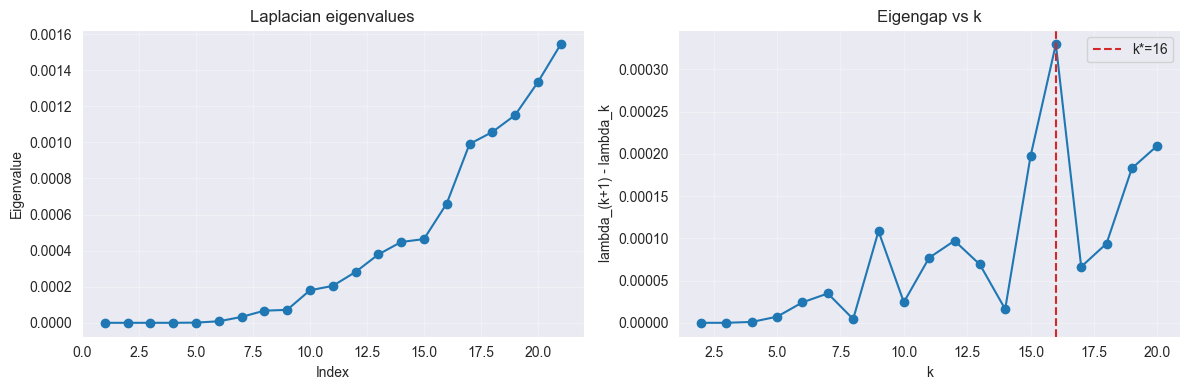

k_best_eigengap = 16
Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\spectral_eigengap_decision.png


In [58]:
# Eigengap heuristic
L = laplacian(W, normed=True)

k_eigs = min(MAX_K_EIGENGAP + 1, n_nodes - 1)
if k_eigs < 3:
    raise ValueError('Not enough nodes to run eigengap analysis')

eigvals, eigvecs = eigsh(L, k=k_eigs, which='SM')
order = np.argsort(eigvals)
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

k_candidates = np.arange(2, min(MAX_K_EIGENGAP, len(eigvals) - 1) + 1)
gap_by_k = np.array([eigvals[k] - eigvals[k - 1] for k in k_candidates])
k_best_eigengap = int(k_candidates[np.argmax(gap_by_k)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(eigvals) + 1), eigvals, marker='o')
axes[0].set_title('Laplacian eigenvalues')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_candidates, gap_by_k, marker='o')
axes[1].axvline(k_best_eigengap, linestyle='--', color='tab:red', label=f'k*={k_best_eigengap}')
axes[1].set_title('Eigengap vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('lambda_(k+1) - lambda_k')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
out_path = FIG_DIR / 'spectral_eigengap_decision.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print('k_best_eigengap =', k_best_eigengap)
print('Figure saved to:', out_path)

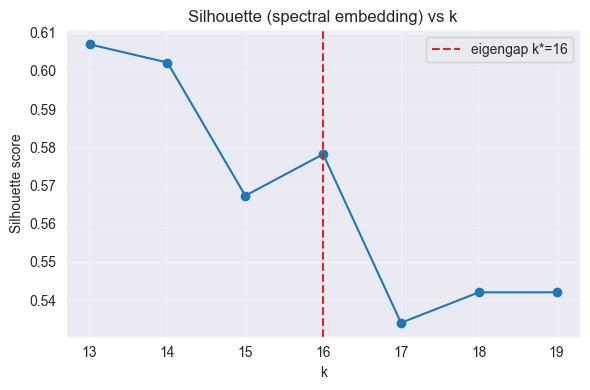

,k,silhouette_embedding
0,13,0.606952
1,14,0.602192
2,15,0.567339
3,16,0.578202
4,17,0.534080
5,18,0.542054
6,19,0.542061


In [59]:
# Additional decision support plot: silhouette in spectral-embedding space
# (supportive metric, while eigengap remains the primary selection criterion)

k_min = max(2, k_best_eigengap - 3)
k_max = min(MAX_K_EIGENGAP, k_best_eigengap + 3)
k_eval = list(range(k_min, k_max + 1))

embedding = eigvecs[:, 1:] if eigvecs.shape[1] > 1 else eigvecs
sil_scores = []

for k in k_eval:
    model_k = SpectralClustering(
        n_clusters=k,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=42,
        n_init=20
    )
    labels_k = model_k.fit_predict(W)
    dim = min(k, embedding.shape[1])
    sil = silhouette_score(embedding[:, :dim], labels_k, metric='euclidean')
    sil_scores.append(sil)

plt.figure(figsize=(6, 4))
plt.plot(k_eval, sil_scores, marker='o')
plt.axvline(k_best_eigengap, linestyle='--', color='tab:red', label=f'eigengap k*={k_best_eigengap}')
plt.title('Silhouette (spectral embedding) vs k')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out_path = FIG_DIR / 'spectral_silhouette_support.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'k': k_eval, 'silhouette_embedding': sil_scores})

In [60]:
# Final clustering with eigengap-selected k
model_final = SpectralClustering(
    n_clusters=k_best_eigengap,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42,
    n_init=50
)
labels_final = model_final.fit_predict(W)

gdf_nodos['segmento'] = labels_final
manzanas_completas['segmento'] = labels_final

print('Final k (eigengap):', k_best_eigengap)
print(manzanas_completas['segmento'].value_counts().sort_index())

Final k (eigengap): 16
segmento
0     1290
1        2
2        2
3        9
4        9
5        2
6     1446
7       24
8       29
9      343
10       9
11      54
12     654
13      36
14     243
15    1228
Name: count, dtype: int64


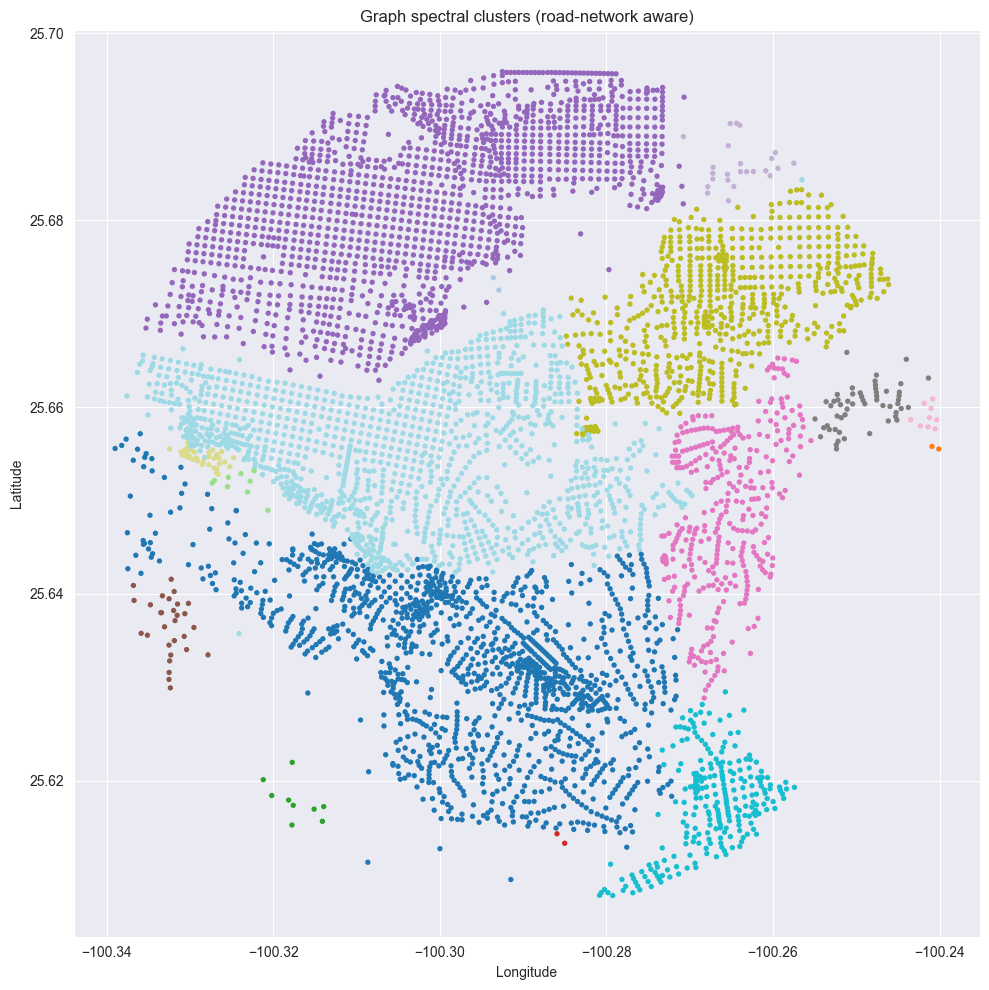

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\graph_spectral_clusters_map.png


In [61]:
# Cluster map (same structure style: lon/lat scatter + color by cluster)
plt.figure(figsize=(10, 10))
plt.scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento'],
    cmap='tab20',
    s=8
)
plt.title('Graph spectral clusters (road-network aware)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
out_path = FIG_DIR / 'graph_spectral_clusters_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)



Rule: if a cluster has fewer than 200 nodes, reassign its nodes to the closest major cluster.

Implementation details:
- Major clusters: clusters with `n >= 200`.
- Closeness: shortest-path distance on the road network from each small-cluster node to representative nodes of major clusters.
- Representative node of each major cluster: node closest to its geometric centroid in projected coordinates.
- Fallback: if no finite graph path is available, choose closest major cluster by projected Euclidean distance to major centroid.

In [62]:
MIN_CLUSTER_SIZE = 200

cluster_counts_before = manzanas_completas['segmento'].value_counts().sort_index()
major_clusters = cluster_counts_before[cluster_counts_before >= MIN_CLUSTER_SIZE].index.tolist()
small_clusters = cluster_counts_before[cluster_counts_before < MIN_CLUSTER_SIZE].index.tolist()

print('Cluster counts BEFORE merge:')
print(cluster_counts_before)
print('Major clusters (n >= 200):', major_clusters)
print('Small clusters (n < 200):', small_clusters)

if len(major_clusters) == 0:
    raise ValueError('No major clusters found; cannot apply merge heuristic with MIN_CLUSTER_SIZE=200')

Cluster counts BEFORE merge:
segmento
0     1290
1        2
2        2
3        9
4        9
5        2
6     1446
7       24
8       29
9      343
10       9
11      54
12     654
13      36
14     243
15    1228
Name: count, dtype: int64
Major clusters (n >= 200): [0, 6, 9, 12, 14, 15]
Small clusters (n < 200): [1, 2, 3, 4, 5, 7, 8, 10, 11, 13]


In [63]:
# Prepare projected node table with cluster labels
gdf_nodos_utm = gdf_nodos_utm.copy()
gdf_nodos_utm['segmento'] = gdf_nodos['segmento'].values

# Major cluster centroids (projected XY)
major_centroids = (
    gdf_nodos_utm[gdf_nodos_utm['segmento'].isin(major_clusters)]
    .groupby('segmento')
    .agg(cx=('geometry', lambda s: s.x.mean()),
         cy=('geometry', lambda s: s.y.mean()))
)

# Representative graph node per major cluster (closest to major centroid)
major_rep_graph_node = {}
for c in major_clusters:
    sub = gdf_nodos_utm[gdf_nodos_utm['segmento'] == c].copy()
    cx, cy = major_centroids.loc[c, 'cx'], major_centroids.loc[c, 'cy']
    d2 = (sub.geometry.x - cx) ** 2 + (sub.geometry.y - cy) ** 2
    rep_idx = d2.idxmin()
    major_rep_graph_node[c] = int(sub.loc[rep_idx, 'graph_node'])

major_rep_graph_node

{0: 1423289156,
 6: 344482432,
 9: 1682151705,
 12: 1040788466,
 14: 7054914800,
 15: 930970437}

In [64]:
# Reassign each node from small clusters to closest major cluster by shortest-path distance
sp_cache_reassign = {}

def sp_len_cached(a, b):
    key = (a, b) if a <= b else (b, a)
    if key in sp_cache_reassign:
        return sp_cache_reassign[key]
    if a == b:
        sp_cache_reassign[key] = 0.0
        return 0.0
    try:
        d = float(nx.shortest_path_length(G_proj, source=a, target=b, weight='length'))
    except nx.NetworkXNoPath:
        d = np.inf
    sp_cache_reassign[key] = d
    return d

seg_merged = gdf_nodos_utm['segmento'].copy()
major_cxy = {c: (major_centroids.loc[c, 'cx'], major_centroids.loc[c, 'cy']) for c in major_clusters}

mask_small = gdf_nodos_utm['segmento'].isin(small_clusters)
idx_small = gdf_nodos_utm[mask_small].index.tolist()

for idx in idx_small:
    node_id = int(gdf_nodos_utm.loc[idx, 'graph_node'])

    best_c = None
    best_d = np.inf

    for c in major_clusters:
        d = sp_len_cached(node_id, major_rep_graph_node[c])
        if d < best_d:
            best_d = d
            best_c = c

    if np.isfinite(best_d):
        seg_merged.loc[idx] = best_c
    else:
        # fallback if disconnected: nearest major centroid in projected Euclidean space
        x0, y0 = gdf_nodos_utm.loc[idx, 'geometry'].x, gdf_nodos_utm.loc[idx, 'geometry'].y
        best_c_e = min(major_clusters, key=lambda c: (x0 - major_cxy[c][0])**2 + (y0 - major_cxy[c][1])**2)
        seg_merged.loc[idx] = best_c_e

# Optional relabel to contiguous ids sorted by descending size (for cleaner downstream reports)
counts_tmp = seg_merged.value_counts().sort_values(ascending=False)
new_label_map = {old_lbl: new_lbl for new_lbl, old_lbl in enumerate(counts_tmp.index.tolist())}
seg_merged_compact = seg_merged.map(new_label_map).astype(int)

# Update all relevant tables
gdf_nodos['segmento_original'] = gdf_nodos['segmento']
gdf_nodos_utm['segmento_original'] = gdf_nodos_utm['segmento']
manzanas_completas['segmento_original'] = manzanas_completas['segmento']

gdf_nodos['segmento'] = seg_merged_compact.values
gdf_nodos_utm['segmento'] = seg_merged_compact.values
manzanas_completas['segmento'] = seg_merged_compact.values

cluster_counts_after = manzanas_completas['segmento'].value_counts().sort_index()

print('Cluster counts AFTER merge/relabel:')
print(cluster_counts_after)
print('Final number of clusters:', cluster_counts_after.shape[0])
print('Label map old->new:')
print(new_label_map)

Cluster counts AFTER merge/relabel:
segmento
0    1448
1    1337
2    1264
3     681
4     405
5     245
Name: count, dtype: int64
Final number of clusters: 6
Label map old->new:
{6: 0, 0: 1, 15: 2, 12: 3, 9: 4, 14: 5}


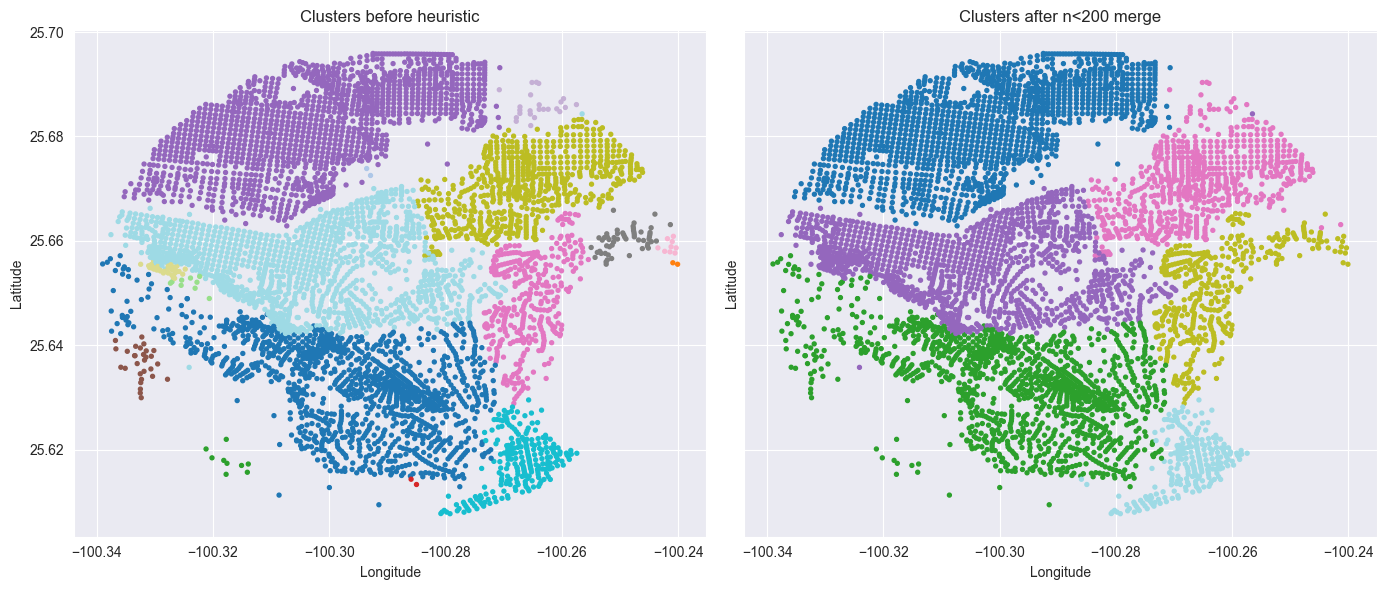

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\graph_spectral_clusters_before_after_merge.png


In [65]:
# Before vs after figure (same style as cluster scatter map)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento_original'],
    cmap='tab20',
    s=8
)
axes[0].set_title('Clusters before heuristic')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento'],
    cmap='tab20',
    s=8
)
axes[1].set_title('Clusters after n<200 merge')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
out_path = FIG_DIR / 'graph_spectral_clusters_before_after_merge.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

 MCA (categorical multivariate analysis)

We now use MCA to build a socio-urban composite index from categorical versions of the indicators.

Compatibility decision for downstream cells:
- `MCA1` is the first MCA axis score.
- We use `MCA1` as the main socio-urban score in downstream modeling.

In [66]:
import prince

cols_mca = [
    'POBTOT', 'POBFEM', 'POBMAS',
    'POB0_14_P', 'P15A29A_P', 'P30A59A_P',
    'P_60YMAS_P', 'P_CD_P', 'GRAPROES',
    'VIVTOT', 'VIVPAR', 'VIVPAR_P', 'TVIPAHAB', 'TVIPAHAB_P',
    'VIVNOHAB_P', 'PRO_OCUP_C',
    'V3MASOCU_P', 'VPH_PIDT_P', 'VPH_C_EL_P',
    'VPH_EXSA_P', 'VPH_DREN_P', 'RECUCALL_C',
    'RAMPAS_C', 'PASOPEAT_C', 'BANQUETA_C', 'GUARNICI_C', 'CICLOVIA_C',
    'CICLOCAR_C', 'ALUMPUB_C', 'LETRERO_C', 'TELPUB_C', 'ARBOLES_C',
    'DRENAJEP_C', 'TRANSCOL_C', 'ACESOPER_C', 'ACESOAUT_C', 'PUESSEMI_C',
    'PUESAMBU_C'
]

missing_cols = [c for c in cols_mca if c not in manzanas_completas.columns]
if missing_cols:
    raise ValueError(f'Missing columns for MCA: {missing_cols}')

X_mca_base = manzanas_completas[cols_mca].copy()
print('X_mca_base shape:', X_mca_base.shape)
X_mca_base.head(3)

X_mca_base shape: (5380, 38)


,POBTOT,POBFEM,POBMAS,POB0_14_P,P15A29A_P,P30A59A_P,P_60YMAS_P,P_CD_P,GRAPROES,VIVTOT,VIVPAR,VIVPAR_P,TVIPAHAB,TVIPAHAB_P,VIVNOHAB_P,PRO_OCUP_C,V3MASOCU_P,VPH_PIDT_P,VPH_C_EL_P,VPH_EXSA_P,VPH_DREN_P,RECUCALL_C,RAMPAS_C,PASOPEAT_C,BANQUETA_C,GUARNICI_C,CICLOVIA_C,CICLOCAR_C,ALUMPUB_C,LETRERO_C,TELPUB_C,ARBOLES_C,DRENAJEP_C,TRANSCOL_C,ACESOPER_C,ACESOAUT_C,PUESSEMI_C,PUESAMBU_C
5,83,43,40,15.66,13.25,40.96,30.12,7.23,14.43,24,24,100.0,23,95.83,4.17,0.67,0.0,100.0,95.65,95.65,95.65,1,3,3,1,1,3,3,2,1,3,2,3,3,3,3,3,3
6,116,63,53,16.38,26.72,43.97,12.93,0.00,15.29,37,37,100.0,37,100.00,0.00,0.58,0.0,100.0,100.00,100.00,100.00,1,3,2,1,1,3,3,2,2,3,1,3,3,3,3,3,3
7,57,28,29,17.54,24.56,24.56,33.33,19.30,6.77,14,14,100.0,13,92.86,7.14,0.88,0.0,100.0,100.00,100.00,100.00,1,3,3,1,1,3,3,2,2,2,2,3,3,3,3,3,2


In [67]:
# Intermediate check: missingness and cardinality before categorization
summary_mca = pd.DataFrame({
    'missing_pct': X_mca_base.isna().mean() * 100,
    'n_unique': X_mca_base.nunique(dropna=True)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
summary_mca.head(15)

,missing_pct,n_unique
P_60YMAS_P,0.0,1672
POB0_14_P,0.0,1503
P15A29A_P,0.0,1396
P30A59A_P,0.0,1328
GRAPROES,0.0,987
P_CD_P,0.0,756
TVIPAHAB_P,0.0,527
VIVNOHAB_P,0.0,511
POBTOT,0.0,333
POBFEM,0.0,197


In [68]:
def to_mca_category(series: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(series, errors='coerce')

    miss = x.isna()
    n_unique = x.nunique(dropna=True)

    if n_unique == 0:
        out = pd.Series('MISSING', index=series.index, dtype='object')
        return out

    if n_unique <= q:
        out = x.round(6).astype('string')
        out[miss] = 'MISSING'
        return out.astype('category')

    try:
        binned = pd.qcut(x, q=q, duplicates='drop')
        out = binned.astype('string')
    except Exception:
        binned = pd.cut(x, bins=min(q, max(2, n_unique)), duplicates='drop')
        out = binned.astype('string')

    out[miss] = 'MISSING'
    return out.astype('category')

X_mca_cat = pd.DataFrame({c: to_mca_category(X_mca_base[c], q=5) for c in cols_mca})

print('Categorized matrix shape:', X_mca_cat.shape)
print('Example categories counts (first 5 vars):')
for c in cols_mca[:5]:
    print(c, '->', X_mca_cat[c].nunique())

# Prince compatibility: explicitly build dense numeric one-hot matrix
# to avoid sparse/object dtype issues across scipy/pandas versions.
X_mca_ready = pd.get_dummies(X_mca_cat.astype(str), drop_first=False, dtype=float)
print('One-hot MCA matrix shape:', X_mca_ready.shape)
print('One-hot dtypes unique:', pd.Series(X_mca_ready.dtypes.astype(str)).value_counts().to_dict())

X_mca_cat.head(3)


Categorized matrix shape: (5380, 38)
Example categories counts (first 5 vars):
POBTOT -> 5
POBFEM -> 5
POBMAS -> 5
POB0_14_P -> 5
P15A29A_P -> 5
One-hot MCA matrix shape: (5380, 127)
One-hot dtypes unique: {'float64': 127}


,POBTOT,POBFEM,POBMAS,POB0_14_P,P15A29A_P,P30A59A_P,P_60YMAS_P,P_CD_P,GRAPROES,VIVTOT,VIVPAR,VIVPAR_P,TVIPAHAB,TVIPAHAB_P,VIVNOHAB_P,PRO_OCUP_C,V3MASOCU_P,VPH_PIDT_P,VPH_C_EL_P,VPH_EXSA_P,VPH_DREN_P,RECUCALL_C,RAMPAS_C,PASOPEAT_C,BANQUETA_C,GUARNICI_C,CICLOVIA_C,CICLOCAR_C,ALUMPUB_C,LETRERO_C,TELPUB_C,ARBOLES_C,DRENAJEP_C,TRANSCOL_C,ACESOPER_C,ACESOAUT_C,PUESSEMI_C,PUESAMBU_C
5,"(78.0, 119.0]","(40.0, 60.0]","(38.0, 59.0]","(12.5, 17.764]","(10.71, 19.23]","(39.58, 43.75]","(27.5, 90.0]","(6.87, 70.0]","(14.27, 19.0]","(17.0, 26.0]","(17.0, 26.0]","(-2.001, 100.0]","(15.0, 23.0]","(91.18, 96.3]","(0.0, 5.0]","(0.61, 0.74]","(-2.001, 0.0]","(94.44, 100.0]","(-2.001, 100.0]","(-2.001, 98.298]","(-2.001, 100.0]","(0.999, 9.0]","(2.0, 3.0]","(2.0, 3.0]","(0.999, 2.0]","(0.999, 2.0]",3,3,"(0.999, 2.0]","(0.999, 2.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 3.0]","(2.0, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]"
6,"(78.0, 119.0]","(60.0, 1019.0]","(38.0, 59.0]","(12.5, 17.764]","(23.33, 27.91]","(43.75, 100.0]","(12.388, 19.72]","(-2.001, 0.0]","(14.27, 19.0]","(26.0, 39.0]","(26.0, 39.0]","(-2.001, 100.0]","(35.0, 751.0]","(96.3, 100.0]","(-2.001, 0.0]","(0.46, 0.61]","(-2.001, 0.0]","(94.44, 100.0]","(-2.001, 100.0]","(98.298, 100.0]","(-2.001, 100.0]","(0.999, 9.0]","(2.0, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]",3,3,"(0.999, 2.0]","(0.999, 2.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 3.0]","(2.0, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]"
7,"(49.0, 78.0]","(25.0, 40.0]","(24.0, 38.0]","(12.5, 17.764]","(23.33, 27.91]","(-2.001, 28.47]","(27.5, 90.0]","(6.87, 70.0]","(-2.001, 7.9]","(7.0, 17.0]","(7.0, 17.0]","(-2.001, 100.0]","(6.0, 15.0]","(91.18, 96.3]","(5.0, 10.0]","(0.74, 0.92]","(-2.001, 0.0]","(94.44, 100.0]","(-2.001, 100.0]","(98.298, 100.0]","(-2.001, 100.0]","(0.999, 9.0]","(2.0, 3.0]","(2.0, 3.0]","(0.999, 2.0]","(0.999, 2.0]",3,3,"(0.999, 2.0]","(0.999, 2.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 3.0]","(2.0, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]"


In [69]:
# Fit MCA
n_components_mca = 7
mca = prince.MCA(
    n_components=n_components_mca,
    n_iter=10,
    copy=True,
    check_input=True,
    one_hot=False,
    random_state=42
)

Z_mca = mca.fit_transform(X_mca_ready)
Z_mca.columns = [f'MCA{i+1}' for i in range(Z_mca.shape[1])]

print('MCA scores shape:', Z_mca.shape)
Z_mca.head(3)


MCA scores shape: (5380, 7)


,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7
5,-0.291217,0.127672,-0.101224,0.498695,0.157454,-0.318813,0.177916
6,-0.240443,0.129512,0.206053,0.168566,-0.317070,-0.270966,0.283653
7,-0.186784,0.041106,-0.381828,-0.078407,0.200923,-0.069780,0.163216


In [70]:
# Extract explained inertia / variance-style summary (version-robust)
if hasattr(mca, 'percentage_of_variance_') and mca.percentage_of_variance_ is not None:
    explained = np.array(mca.percentage_of_variance_, dtype=float)
    if explained.max() > 1.0:
        explained = explained / 100.0
elif hasattr(mca, 'eigenvalues_') and mca.eigenvalues_ is not None:
    ev = np.array(mca.eigenvalues_, dtype=float)
    explained = ev / ev.sum() if ev.sum() > 0 else ev
else:
    explained = np.repeat(np.nan, Z_mca.shape[1])

cum_explained = np.nancumsum(explained)

print('Explained (first components):')
print(np.round(explained, 4))
print('Cumulative explained:')
print(np.round(cum_explained, 4))

Explained (first components):
[0.1653 0.1341 0.0649 0.051  0.0397 0.0309 0.0232]
Cumulative explained:
[0.1653 0.2993 0.3643 0.4153 0.455  0.4859 0.5091]


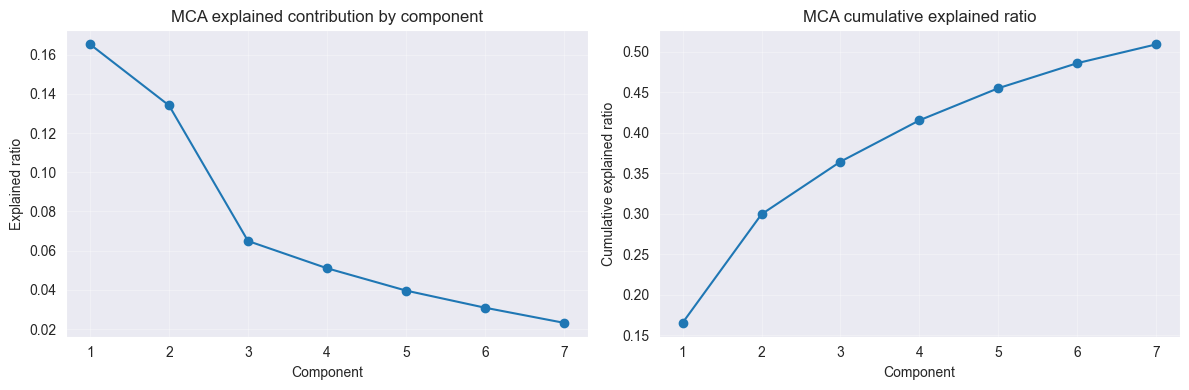

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\mca_explained_components.png


In [71]:
# Decision-style plots for MCA components (analogous to PCA diagnostics)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(1, len(explained) + 1), explained, marker='o')
axes[0].set_title('MCA explained contribution by component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained ratio')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, len(cum_explained) + 1), cum_explained, marker='o')
axes[1].set_title('MCA cumulative explained ratio')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Cumulative explained ratio')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / 'mca_explained_components.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

In [72]:
# Intermediate interpretation: top contributing variables to MCA1
# Prince returns contributions by one-hot levels; aggregate by original variable prefix.
col_contrib = mca.column_contributions_.copy()
col_contrib.columns = [f'MCA{i+1}' for i in range(col_contrib.shape[1])]

var_prefixes = sorted(cols_mca, key=len, reverse=True)

def original_var(level_name: str) -> str:
    s = str(level_name)
    for v in var_prefixes:
        if s.startswith(v):
            return v
    return s.split('_')[0]

col_contrib['variable'] = [original_var(ix) for ix in col_contrib.index]
var_contrib = col_contrib.groupby('variable').sum(numeric_only=True).sort_values('MCA1', ascending=False)

var_contrib.head(15)

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7
variable,,,,,,,
LETRERO_C,0.046770,0.028431,0.000324,0.000993,6.345503e-05,0.066276,0.006592
CICLOCAR_C,0.045967,0.028645,0.001682,0.001425,3.575669e-04,0.001614,0.178236
CICLOVIA_C,0.045959,0.028589,0.001565,0.001416,3.665648e-04,0.001978,0.178827
TRANSCOL_C,0.045601,0.027811,0.000732,0.000265,3.060397e-04,0.002044,0.004589
PASOPEAT_C,0.045501,0.027054,0.000316,0.000342,2.636974e-05,0.008823,0.003969
RAMPAS_C,0.045418,0.027124,0.004144,0.000192,2.159429e-05,0.000552,0.031034
TELPUB_C,0.045385,0.026673,0.000316,0.000191,1.838285e-05,0.000532,0.000404
PUESSEMI_C,0.045385,0.026673,0.000316,0.000191,1.838285e-05,0.000532,0.000404
PUESAMBU_C,0.045385,0.026673,0.000316,0.000191,1.838285e-05,0.000532,0.000404


In [73]:
# Expose MCA dimensions clearly for downstream model code
manzanas_completas = manzanas_completas.copy()
for i in range(Z_mca.shape[1]):
    manzanas_completas[f'MCA{i+1}'] = Z_mca.iloc[:, i].values

# Main score used in this pipeline
manzanas_completas['MCA1'] = Z_mca.iloc[:, 0].values

# Optional legacy aliases (not used by default anymore)
manzanas_completas['PC1'] = manzanas_completas['MCA1']
if 'MCA2' in manzanas_completas.columns:
    manzanas_completas['PC2'] = manzanas_completas['MCA2']
if 'MCA3' in manzanas_completas.columns:
    manzanas_completas['PC3'] = manzanas_completas['MCA3']

manzanas_completas[['MCA1']].describe()


,MCA1
count,5.380000e+03
mean,-9.773264e-17
std,6.222035e-01
min,-3.950905e-01
25%,-3.273437e-01
50%,-2.467377e-01
75%,3.121025e-03
max,3.387746e+00


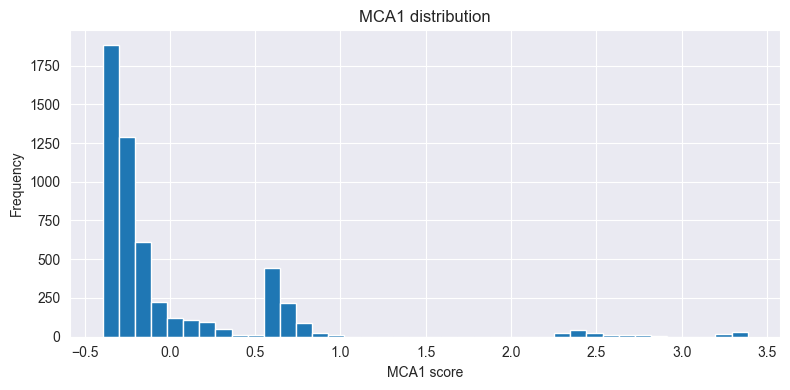

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\mca1_histogram.png


In [74]:
# Distribution plot for MCA1
plt.figure(figsize=(8, 4))
plt.hist(manzanas_completas['MCA1'].dropna(), bins=40)
plt.title('MCA1 distribution')
plt.xlabel('MCA1 score')
plt.ylabel('Frequency')
plt.tight_layout()
out_path = FIG_DIR / 'mca1_histogram.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

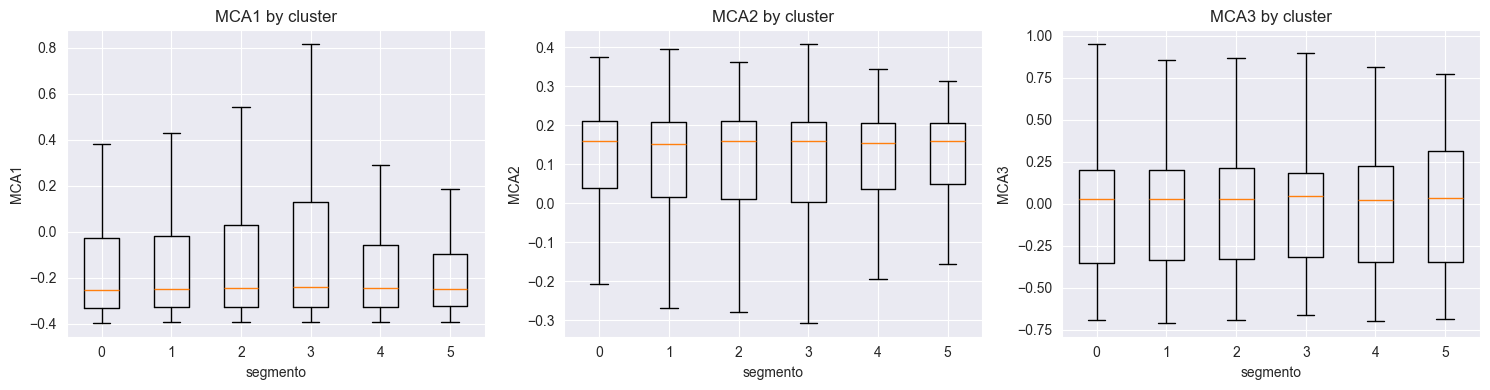

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\mca_dims_by_cluster_boxplot.png


In [75]:
# Cluster-wise boxplots for first available MCA axes (analogous structure to PCA section)
plot_dims = [c for c in ['MCA1', 'MCA2', 'MCA3'] if c in manzanas_completas.columns]
clusters_sorted = sorted(pd.Series(manzanas_completas['segmento']).dropna().unique())

if len(plot_dims) == 0:
    raise ValueError('No MCA dimensions found for plotting')

fig, axes = plt.subplots(1, len(plot_dims), figsize=(5 * len(plot_dims), 4), sharey=False)
if len(plot_dims) == 1:
    axes = [axes]

for ax, dim in zip(axes, plot_dims):
    data = [manzanas_completas.loc[manzanas_completas['segmento'] == k, dim].dropna() for k in clusters_sorted]
    ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
    ax.set_title(f'{dim} by cluster')
    ax.set_xlabel('segmento')
    ax.set_ylabel(dim)

plt.tight_layout()
out_path = FIG_DIR / 'mca_dims_by_cluster_boxplot.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

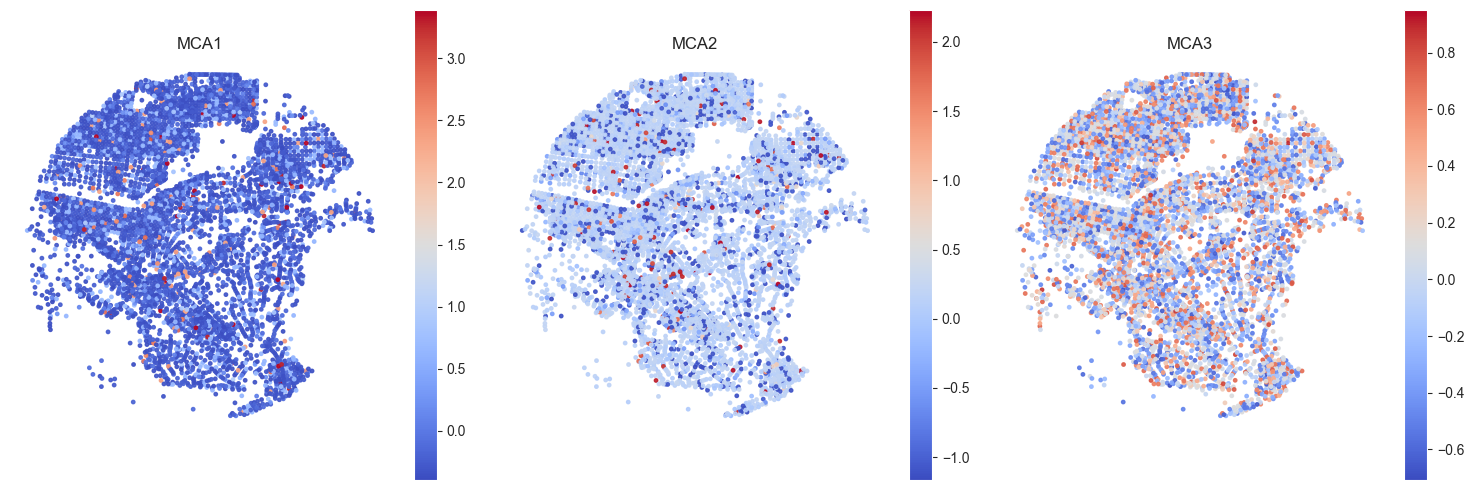

Figure saved to: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\mca123_spatial_maps.png


In [76]:
# MCA1/MCA2/MCA3 spatial maps
g = manzanas_completas.copy()
if 'geometry' not in g.columns:
    g = gpd.GeoDataFrame(g, geometry=gpd.points_from_xy(g['lon'], g['lat']), crs='EPSG:4326')
else:
    g = gpd.GeoDataFrame(g, geometry='geometry', crs='EPSG:4326')

g = g.to_crs(epsg=3857)
cols = [c for c in ['MCA1', 'MCA2', 'MCA3'] if c in g.columns]
cmap = 'coolwarm'

if len(cols) == 0:
    raise ValueError('No MCA1/MCA2/MCA3 columns found for spatial plotting')

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 5))
if len(cols) == 1:
    axes = [axes]

geom_type = g.geometry.iloc[0].geom_type
for ax, c_name in zip(axes, cols):
    if geom_type in ('Polygon', 'MultiPolygon'):
        g.plot(ax=ax, column=c_name, cmap=cmap, legend=True, linewidth=0.2, edgecolor='white')
    else:
        g.plot(ax=ax, column=c_name, cmap=cmap, markersize=6, legend=True, alpha=0.9)
    ax.set_title(c_name, fontsize=12)
    ax.set_axis_off()

plt.tight_layout()
out_path = FIG_DIR / 'mca123_spatial_maps.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)


p-median optimization setup

In [77]:
import math
from collections import defaultdict

import pulp

In [78]:
# Directories and model hyperparameters
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'resultados_clusters'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

D_MAX = 366.0
S_MIN = 240.0
BETA = 0.25
P_NEW_PER_CLUSTER = 5
PENALTY_UNCOVERED = 5000.0
TIME_LIMIT_SEC = 300

print('RESULTS_DIR =', RESULTS_DIR)
print({'D_MAX': D_MAX, 'S_MIN': S_MIN, 'BETA': BETA, 'P_NEW_PER_CLUSTER': P_NEW_PER_CLUSTER, 'PENALTY_UNCOVERED': PENALTY_UNCOVERED})

RESULTS_DIR = C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\tables\resultados_clusters
{'D_MAX': 366.0, 'S_MIN': 240.0, 'BETA': 0.25, 'P_NEW_PER_CLUSTER': 5, 'PENALTY_UNCOVERED': 5000.0}


In [79]:
# Build condensed table (compatible with previous pipeline naming)
if len(manzanas_completas) != len(gdf_nodos):
    raise ValueError('Length mismatch between manzanas_completas and gdf_nodos; cannot align graph_node reliably')

data_condensed = manzanas_completas[['lat', 'lon', 'segmento', 'POBTOT', 'oxxo_presente', 'MCA1', 'es_candidato']].copy().reset_index(drop=True)
data_condensed['segmento_gmm'] = data_condensed['segmento']  # compatibility alias
data_condensed['node_id'] = np.arange(len(data_condensed), dtype=int)
data_condensed['graph_node'] = gdf_nodos.reset_index(drop=True)['graph_node'].astype(int).values

condensed_path = PROCESSED_DIR / 'condensado.csv'
data_condensed.to_csv(condensed_path, index=False)
print('Saved:', condensed_path)
print('condensado shape:', data_condensed.shape)
data_condensed.head(3)

Saved: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\condensado.csv
condensado shape: (5380, 10)


,lat,lon,segmento,POBTOT,oxxo_presente,MCA1,es_candidato,segmento_gmm,node_id,graph_node
0,25.673922,-100.260181,3,83,0,-0.291217,False,3,0,1038727763
1,25.673781,-100.252587,3,116,0,-0.240443,False,3,1,1040458471
2,25.657625,-100.314492,2,57,0,-0.186784,False,2,2,4468143780


In [80]:

def build_pmedian_inputs_graph(df_plot, G_graph, D_MAX=366.0, S_MIN=240.0, beta=0.25, cluster_col='segmento'):
    # Build p-median sets using shortest-path graph distances.

    req = ['node_id', 'graph_node', 'lat', 'lon', cluster_col, 'POBTOT', 'MCA1', 'oxxo_presente', 'es_candidato']
    miss = [c for c in req if c not in df_plot.columns]
    if miss:
        raise ValueError(f'Missing required columns for p-median build: {miss}')

    df = df_plot.copy().reset_index(drop=True)

    df['node_id'] = pd.to_numeric(df['node_id'], errors='coerce').astype('Int64')
    df['graph_node'] = pd.to_numeric(df['graph_node'], errors='coerce').astype('Int64')
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df['POBTOT'] = pd.to_numeric(df['POBTOT'], errors='coerce').fillna(0.0)
    df['MCA1'] = pd.to_numeric(df['MCA1'], errors='coerce').fillna(0.0)
    df['oxxo_presente'] = pd.to_numeric(df['oxxo_presente'], errors='coerce').fillna(0).astype(int)
    df['es_candidato'] = df['es_candidato'].astype(bool)
    df[cluster_col] = pd.to_numeric(df[cluster_col], errors='coerce').fillna(-1).astype(int)

    df = df.dropna(subset=['node_id', 'graph_node', 'lat', 'lon']).copy()
    df['node_id'] = df['node_id'].astype(int)
    df['graph_node'] = df['graph_node'].astype(int)

    # I: demand
    df_I = df[df['POBTOT'] > 0][['node_id', 'graph_node', 'POBTOT', 'MCA1', 'lat', 'lon', cluster_col]].copy()
    df_I.rename(columns={cluster_col: 'cluster_i'}, inplace=True)

    mca1 = df_I['MCA1'].astype(float)
    std = float(mca1.std(ddof=0)) if len(mca1) > 1 else 0.0
    denom = std if np.isfinite(std) and std > 0 else 1.0
    mca1_z = (mca1 - float(mca1.mean())) / denom
    w = df_I['POBTOT'] * (1.0 + beta * mca1_z.fillna(0.0))
    df_I['w'] = w.clip(lower=0.0)
    df_I['i'] = np.arange(len(df_I), dtype=int)

    # E: existing
    df_E = df[df['oxxo_presente'] > 0][['node_id', 'graph_node', 'lat', 'lon', cluster_col]].copy()
    df_E.rename(columns={cluster_col: 'cluster_p'}, inplace=True)
    df_E['p'] = np.arange(len(df_E), dtype=int)
    df_E['es_existente'] = True

    # J raw candidates
    df_J_raw = df[(df['oxxo_presente'] == 0) & (df['es_candidato'])][['node_id', 'graph_node', 'lat', 'lon', cluster_col]].copy()
    df_J_raw.rename(columns={cluster_col: 'cluster_p'}, inplace=True)

    # Filter J by S_MIN to existing (graph shortest path)
    if len(df_E) > 0 and len(df_J_raw) > 0:
        dist_to_E = nx.multi_source_dijkstra_path_length(
            G_graph,
            sources=set(df_E['graph_node'].astype(int).unique().tolist()),
            weight='length'
        )
        dvals = df_J_raw['graph_node'].map(lambda n: float(dist_to_E.get(int(n), np.inf)))
        df_J = df_J_raw[dvals >= S_MIN].copy()
    else:
        df_J = df_J_raw.copy()

    df_J = df_J.reset_index(drop=True)
    df_J['j'] = np.arange(len(df_J), dtype=int)
    df_J['p'] = np.arange(len(df_E), len(df_E) + len(df_J), dtype=int)
    df_J['es_existente'] = False

    # P = E union J
    colsP = ['p', 'node_id', 'graph_node', 'lat', 'lon', 'cluster_p', 'es_existente']
    df_P = pd.concat([df_E[colsP], df_J[colsP]], ignore_index=True)

    # A arcs (i,p) within D_MAX graph distance
    p_by_node = defaultdict(list)
    for r in df_P.itertuples(index=False):
        p_by_node[int(r.graph_node)].append(int(r.p))
    p_nodes = set(p_by_node.keys())

    i_by_node = defaultdict(list)
    for r in df_I.itertuples(index=False):
        i_by_node[int(r.graph_node)].append(int(r.i))

    arc_rows = []
    total_sources = len(i_by_node)
    for n_src, (src_node, i_list) in enumerate(i_by_node.items(), start=1):
        lengths = nx.single_source_dijkstra_path_length(
            G_graph,
            source=int(src_node),
            cutoff=float(D_MAX),
            weight='length'
        )

        p_dist = []
        for node, dist in lengths.items():
            if node in p_nodes:
                for p in p_by_node[node]:
                    p_dist.append((int(p), float(dist)))

        if p_dist:
            for i_id in i_list:
                for p_id, d in p_dist:
                    arc_rows.append((int(i_id), int(p_id), float(d)))

        if (n_src % 300 == 0) or (n_src == total_sources):
            print(f'Arcs progress: {n_src}/{total_sources} source nodes')

    df_A = pd.DataFrame(arc_rows, columns=['i', 'p', 'dist_m'])
    if len(df_A) > 0:
        df_A = (
            df_A.groupby(['i', 'p'], as_index=False)['dist_m']
            .min()
            .sort_values(['i', 'p'])
            .reset_index(drop=True)
        )

    # Candidate conflicts (j,k) if graph distance < S_MIN
    conflict_rows = []
    if len(df_J) > 1:
        gdfJ = gpd.GeoDataFrame(
            df_J[['j', 'graph_node', 'lat', 'lon']].copy(),
            geometry=gpd.points_from_xy(df_J['lon'], df_J['lat']),
            crs='EPSG:4326'
        ).to_crs(epsg=PROJ_EPSG)

        coords = np.column_stack([gdfJ.geometry.x.values, gdfJ.geometry.y.values])
        nbrs = NearestNeighbors(radius=float(S_MIN), metric='euclidean').fit(coords)
        neigh_idx = nbrs.radius_neighbors(coords, return_distance=False)

        sp_cache = {}

        def sp_cached(a, b):
            key = (a, b) if a <= b else (b, a)
            if key in sp_cache:
                return sp_cache[key]
            if a == b:
                sp_cache[key] = 0.0
                return 0.0
            try:
                d = float(nx.shortest_path_length(G_graph, source=int(a), target=int(b), weight='length'))
            except nx.NetworkXNoPath:
                d = np.inf
            sp_cache[key] = d
            return d

        graph_nodes_j = df_J['graph_node'].astype(int).to_numpy()
        j_ids = df_J['j'].astype(int).to_numpy()

        for idx_j, neigh in enumerate(neigh_idx):
            for idx_k in neigh:
                if idx_k <= idx_j:
                    continue
                d_jk = sp_cached(int(graph_nodes_j[idx_j]), int(graph_nodes_j[idx_k]))
                if d_jk < S_MIN:
                    conflict_rows.append((int(j_ids[idx_j]), int(j_ids[idx_k]), float(d_jk)))

    df_conflictos = pd.DataFrame(conflict_rows, columns=['j', 'k', 'dist_m'])
    if len(df_conflictos) > 0:
        df_conflictos = df_conflictos.drop_duplicates(['j', 'k']).reset_index(drop=True)

    params = {
        'D_MAX': float(D_MAX),
        'S_MIN': float(S_MIN),
        'beta': float(beta),
        'n_I': int(len(df_I)),
        'n_E': int(len(df_E)),
        'n_J': int(len(df_J)),
        'n_P': int(len(df_P)),
        'n_A': int(len(df_A)),
        'n_conflictos': int(len(df_conflictos))
    }

    return (
        df_I.reset_index(drop=True),
        df_E.reset_index(drop=True),
        df_J.reset_index(drop=True),
        df_P.reset_index(drop=True),
        df_A,
        df_conflictos,
        params,
    )


In [81]:
df_I, df_E, df_J, df_P, df_A, df_conflictos, params = build_pmedian_inputs_graph(
    data_condensed,
    G_proj,
    D_MAX=D_MAX,
    S_MIN=S_MIN,
    beta=BETA,
    cluster_col='segmento'
)

print('Shapes:')
print('df_I', df_I.shape, 'df_E', df_E.shape, 'df_J', df_J.shape, 'df_P', df_P.shape, 'df_A', df_A.shape, 'df_conflictos', df_conflictos.shape)
print('Params:', params)

Arcs progress: 300/4043 source nodes
Arcs progress: 600/4043 source nodes
Arcs progress: 900/4043 source nodes
Arcs progress: 1200/4043 source nodes
Arcs progress: 1500/4043 source nodes
Arcs progress: 1800/4043 source nodes
Arcs progress: 2100/4043 source nodes
Arcs progress: 2400/4043 source nodes
Arcs progress: 2700/4043 source nodes
Arcs progress: 3000/4043 source nodes
Arcs progress: 3300/4043 source nodes
Arcs progress: 3600/4043 source nodes
Arcs progress: 3900/4043 source nodes
Arcs progress: 4043/4043 source nodes
Shapes:
df_I (4731, 9) df_E (66, 7) df_J (3040, 8) df_P (3106, 7) df_A (59415, 3) df_conflictos (12236, 3)
Params: {'D_MAX': 366.0, 'S_MIN': 240.0, 'beta': 0.25, 'n_I': 4731, 'n_E': 66, 'n_J': 3040, 'n_P': 3106, 'n_A': 59415, 'n_conflictos': 12236}


In [82]:

def pack_pmedian_bundle(df_I, df_P, df_A, df_conflictos=None, params=None):
    params = dict(params or {})
    cols = [
        'kind', 'i', 'p', 'j', 'k', 'w', 'dist_m', 'es_existente', 'name', 'value',
        'uid_i', 'uid_p', 'cluster_i', 'cluster_p'
    ]
    rows = []

    for r in df_I.itertuples(index=False):
        rows.append(dict(kind='I', i=int(r.i), w=float(r.w), uid_i=int(r.node_id), cluster_i=int(r.cluster_i)))

    for r in df_P.itertuples(index=False):
        rows.append(dict(kind='P', p=int(r.p), es_existente=bool(r.es_existente), uid_p=int(r.node_id), cluster_p=int(r.cluster_p)))

    for r in df_A.itertuples(index=False):
        rows.append(dict(kind='A', i=int(r.i), p=int(r.p), dist_m=float(r.dist_m)))

    if df_conflictos is not None and len(df_conflictos) > 0:
        for r in df_conflictos.itertuples(index=False):
            j, k = int(r.j), int(r.k)
            if j != k:
                j, k = sorted((j, k))
                rows.append(dict(kind='C', j=j, k=k, dist_m=float(r.dist_m)))

    for k, v in params.items():
        rows.append(dict(kind='PARAM', name=str(k), value=v))

    out = pd.DataFrame(rows)
    for c in cols:
        if c not in out.columns:
            out[c] = pd.NA
    return out[cols]


df_bundle = pack_pmedian_bundle(df_I, df_P, df_A, df_conflictos, params)

bundle_csv = PROCESSED_DIR / 'pmedian_bundle.csv'
bundle_parquet = PROCESSED_DIR / 'pmedian_bundle.parquet'
bundle_wc_csv = PROCESSED_DIR / 'pmedian_bundle_with_clusters.csv'
bundle_wc_parquet = PROCESSED_DIR / 'pmedian_bundle_with_clusters.parquet'

df_bundle.to_csv(bundle_csv, index=False)
df_bundle.to_parquet(bundle_parquet, index=False)
df_bundle.to_csv(bundle_wc_csv, index=False)
df_bundle.to_parquet(bundle_wc_parquet, index=False)

print('Saved:', bundle_csv)
print('Saved:', bundle_parquet)
print('Saved:', bundle_wc_csv)
print('Saved:', bundle_wc_parquet)
print('Bundle shape:', df_bundle.shape)


Saved: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\pmedian_bundle.csv
Saved: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\pmedian_bundle.parquet
Saved: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\pmedian_bundle_with_clusters.csv
Saved: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\data\processed\pmedian_bundle_with_clusters.parquet
Bundle shape: (79497, 14)


 Clustered optimization model

In [83]:

def solve_cluster_model(
    cluster_id,
    df_I,
    df_J,
    df_P,
    df_A,
    df_conflictos,
    j_to_p_map,
    p_new_per_cluster=5,
    penalty_uncovered=5000.0,
    time_limit_sec=300,
    solver_msg=False,
):
    I_c = df_I[df_I['cluster_i'] == cluster_id].copy()
    if len(I_c) == 0:
        empty_assign = pd.DataFrame(columns=['i','p','dist_m','uncovered','cluster_solved','lat_i','lon_i','cluster_i','w_i','lat_p','lon_p','cluster_p'])
        empty_open = pd.DataFrame(columns=['id','lat','lon','cluster','opened','cluster_solved'])
        metrics = {
            'cluster': int(cluster_id),
            'opened': 0,
            'n_demands': 0,
            'covered': 0,
            'pct_covered': np.nan,
            'mean_dist_m': np.nan,
            'w_mean_dist_m': np.nan,
            'objective_value': np.nan,
        }
        return empty_assign, empty_open, metrics, 'NO_DEMAND'

    existing_all = df_P[df_P['es_existente']].copy()
    cand_local = df_P[(~df_P['es_existente']) & (df_P['cluster_p'] == cluster_id)].copy()

    P_local = pd.concat([existing_all, cand_local], ignore_index=True)
    P_local_set = set(P_local['p'].astype(int).tolist())

    A_c = df_A[df_A['i'].isin(I_c['i']) & df_A['p'].isin(P_local_set)].copy()

    model = pulp.LpProblem(f'cluster_{cluster_id}_pmedian', pulp.LpMinimize)

    x = {}
    for r in A_c.itertuples(index=False):
        key = (int(r.i), int(r.p))
        x[key] = pulp.LpVariable(f'x_{key[0]}_{key[1]}', lowBound=0, upBound=1, cat='Binary')

    u = {int(i): pulp.LpVariable(f'u_{int(i)}', lowBound=0, upBound=1, cat='Binary') for i in I_c['i'].astype(int).tolist()}
    y = {int(p): pulp.LpVariable(f'y_{int(p)}', lowBound=0, upBound=1, cat='Binary') for p in cand_local['p'].astype(int).tolist()}

    w_map = dict(zip(I_c['i'].astype(int), I_c['w'].astype(float)))

    arcs_by_i = defaultdict(list)
    dist_map = {}
    for r in A_c.itertuples(index=False):
        i_id, p_id, d = int(r.i), int(r.p), float(r.dist_m)
        arcs_by_i[i_id].append(p_id)
        dist_map[(i_id, p_id)] = d

    assign_cost = [w_map[i] * dist_map[(i, p)] * x[(i, p)] for (i, p) in x.keys()]
    uncovered_cost = [penalty_uncovered * w_map[i] * u[i] for i in u.keys()]
    model += pulp.lpSum(assign_cost + uncovered_cost)

    for i_id in I_c['i'].astype(int).tolist():
        p_list = arcs_by_i.get(i_id, [])
        if len(p_list) == 0:
            model += (u[i_id] == 1), f'uncovered_forced_{i_id}'
        else:
            model += (pulp.lpSum(x[(i_id, p)] for p in p_list) + u[i_id] == 1), f'assign_or_uncovered_{i_id}'

    for (i_id, p_id), var in x.items():
        if p_id in y:
            model += (var <= y[p_id]), f'link_{i_id}_{p_id}'

    if len(y) > 0:
        p_target = min(int(p_new_per_cluster), len(y))
        model += (pulp.lpSum(y.values()) == p_target), f'open_exactly_{cluster_id}'

    if len(y) > 0 and len(df_conflictos) > 0:
        for r in df_conflictos.itertuples(index=False):
            p_j = j_to_p_map.get(int(r.j))
            p_k = j_to_p_map.get(int(r.k))
            if (p_j in y) and (p_k in y):
                model += (y[p_j] + y[p_k] <= 1), f'conf_{cluster_id}_{int(r.j)}_{int(r.k)}'

    solver = pulp.PULP_CBC_CMD(msg=solver_msg, timeLimit=int(time_limit_sec))
    model.solve(solver)
    status = pulp.LpStatus.get(model.status, str(model.status))

    p_lookup = df_P.set_index('p')[['node_id','lat','lon','cluster_p','es_existente']].to_dict(orient='index')
    i_lookup = I_c.set_index('i')[['lat','lon','cluster_i','w']].to_dict(orient='index')

    assign_rows = []
    for i_id, i_info in i_lookup.items():
        assigned_p = None
        assigned_d = np.nan
        for p_id in arcs_by_i.get(int(i_id), []):
            var = x.get((int(i_id), int(p_id)))
            if var is not None and pulp.value(var) is not None and pulp.value(var) > 0.5:
                assigned_p = int(p_id)
                assigned_d = float(dist_map[(int(i_id), int(p_id))])
                break

        is_uncovered = 1
        if assigned_p is not None:
            is_uncovered = 0

        row = {
            'i': int(i_id),
            'p': float(assigned_p) if assigned_p is not None else np.nan,
            'dist_m': float(assigned_d) if assigned_p is not None else np.nan,
            'uncovered': int(is_uncovered),
            'cluster_solved': int(cluster_id),
            'lat_i': float(i_info['lat']),
            'lon_i': float(i_info['lon']),
            'cluster_i': int(i_info['cluster_i']),
            'w_i': float(i_info['w']),
            'lat_p': np.nan,
            'lon_p': np.nan,
            'cluster_p': np.nan,
        }

        if assigned_p is not None:
            p_info = p_lookup.get(int(assigned_p), None)
            if p_info is not None:
                row['lat_p'] = float(p_info['lat'])
                row['lon_p'] = float(p_info['lon'])
                row['cluster_p'] = float(p_info['cluster_p'])

        assign_rows.append(row)

    assign_df = pd.DataFrame(assign_rows)

    open_rows = []
    for p_id, var in y.items():
        val = pulp.value(var)
        if val is not None and val > 0.5:
            info = p_lookup[int(p_id)]
            open_rows.append({
                'id': int(info['node_id']),
                'lat': float(info['lat']),
                'lon': float(info['lon']),
                'cluster': int(info['cluster_p']),
                'opened': 1,
                'cluster_solved': int(cluster_id),
            })

    open_df = pd.DataFrame(open_rows, columns=['id','lat','lon','cluster','opened','cluster_solved'])

    covered_df = assign_df[assign_df['uncovered'] == 0].copy()
    covered = int(len(covered_df))
    n_demands = int(len(assign_df))
    pct_covered = (covered / n_demands) if n_demands > 0 else np.nan

    if covered > 0:
        mean_dist = float(covered_df['dist_m'].mean())
        wsum = float(covered_df['w_i'].sum())
        w_mean_dist = float((covered_df['dist_m'] * covered_df['w_i']).sum() / wsum) if wsum > 0 else np.nan
    else:
        mean_dist = np.nan
        w_mean_dist = np.nan

    metrics = {
        'cluster': int(cluster_id),
        'opened': int(len(open_df)),
        'n_demands': int(n_demands),
        'covered': int(covered),
        'pct_covered': float(pct_covered) if pd.notna(pct_covered) else np.nan,
        'mean_dist_m': float(mean_dist) if pd.notna(mean_dist) else np.nan,
        'w_mean_dist_m': float(w_mean_dist) if pd.notna(w_mean_dist) else np.nan,
        'objective_value': float(pulp.value(model.objective)) if pulp.value(model.objective) is not None else np.nan,
    }

    return assign_df, open_df, metrics, status


In [84]:

# Run clustered optimization and export per-cluster/global tables
clusters_to_solve = sorted(df_I['cluster_i'].dropna().astype(int).unique().tolist())
print('Clusters to solve:', clusters_to_solve)

j_to_p_map = dict(df_J[['j', 'p']].astype(int).itertuples(index=False, name=None)) if len(df_J) > 0 else {}

all_assign = []
all_open = []
metrics_rows = []
status_rows = []

for c in clusters_to_solve:
    print(f'\nSolving cluster {c} ...')
    assign_c, open_c, metrics_c, status_c = solve_cluster_model(
        cluster_id=int(c),
        df_I=df_I,
        df_J=df_J,
        df_P=df_P,
        df_A=df_A,
        df_conflictos=df_conflictos,
        j_to_p_map=j_to_p_map,
        p_new_per_cluster=P_NEW_PER_CLUSTER,
        penalty_uncovered=PENALTY_UNCOVERED,
        time_limit_sec=TIME_LIMIT_SEC,
        solver_msg=False,
    )

    status_rows.append({'cluster': int(c), 'solver_status': status_c})

    assign_path = RESULTS_DIR / f'asignaciones_cluster{int(c)}.csv'
    open_path = RESULTS_DIR / f'aperturas_cluster{int(c)}.csv'

    assign_c.to_csv(assign_path, index=False)
    open_c.to_csv(open_path, index=False)

    print(f"  status={status_c} | opened={metrics_c['opened']} | covered={metrics_c['covered']}/{metrics_c['n_demands']}")

    all_assign.append(assign_c)
    all_open.append(open_c)
    metrics_rows.append(metrics_c)

asignaciones_global = pd.concat(all_assign, ignore_index=True) if all_assign else pd.DataFrame(columns=['i','p','dist_m','uncovered','cluster_solved','lat_i','lon_i','cluster_i','w_i','lat_p','lon_p','cluster_p'])
aperturas_global = pd.concat(all_open, ignore_index=True) if all_open else pd.DataFrame(columns=['id','lat','lon','cluster','opened','cluster_solved'])
metrics_por_cluster = pd.DataFrame(metrics_rows).sort_values('cluster').reset_index(drop=True)
status_por_cluster = pd.DataFrame(status_rows).sort_values('cluster').reset_index(drop=True)

covered_global = asignaciones_global[asignaciones_global['uncovered'] == 0].copy()
n_demands_total = int(len(asignaciones_global))
covered_total = int(len(covered_global))

if covered_total > 0:
    mean_dist_total = float(covered_global['dist_m'].mean())
    wsum_total = float(covered_global['w_i'].sum())
    w_mean_dist_total = float((covered_global['dist_m'] * covered_global['w_i']).sum() / wsum_total) if wsum_total > 0 else np.nan
else:
    mean_dist_total = np.nan
    w_mean_dist_total = np.nan

metrics_global = pd.DataFrame([
    {
        'opened_total': int(len(aperturas_global)),
        'n_demands_total': int(n_demands_total),
        'covered_total': int(covered_total),
        'pct_covered_total': float(covered_total / n_demands_total) if n_demands_total > 0 else np.nan,
        'mean_dist_m_total': mean_dist_total,
        'w_mean_dist_m_total': w_mean_dist_total,
    }
])

asignaciones_global.to_csv(RESULTS_DIR / 'asignaciones_global.csv', index=False)
aperturas_global.to_csv(RESULTS_DIR / 'aperturas_global.csv', index=False)
metrics_por_cluster.to_csv(RESULTS_DIR / 'metrics_por_cluster.csv', index=False)
metrics_global.to_csv(RESULTS_DIR / 'metrics_global.csv', index=False)
status_por_cluster.to_csv(RESULTS_DIR / 'solver_status_por_cluster.csv', index=False)

print('\nSaved global results in', RESULTS_DIR)
print('metrics_global:')
print(metrics_global)
print('solver statuses:')
print(status_por_cluster)


Clusters to solve: [0, 1, 2, 3, 4, 5]

Solving cluster 0 ...
  status=Optimal | opened=5 | covered=597/1282

Solving cluster 1 ...
  status=Optimal | opened=5 | covered=296/1177

Solving cluster 2 ...
  status=Optimal | opened=5 | covered=497/1113

Solving cluster 3 ...
  status=Optimal | opened=5 | covered=246/589

Solving cluster 4 ...
  status=Optimal | opened=5 | covered=112/358

Solving cluster 5 ...
  status=Optimal | opened=5 | covered=146/212

Saved global results in C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\tables\resultados_clusters
metrics_global:
   opened_total  n_demands_total  covered_total  pct_covered_total  \
0            30             4731           1894           0.400338   

   mean_dist_m_total  w_mean_dist_m_total  
0         223.376531           227.517924  
solver statuses:
   cluster solver_status
0        0       Optimal
1        1       Optimal
2        2       Optimal
3        3       Optimal
4        4       Opti

visualizations

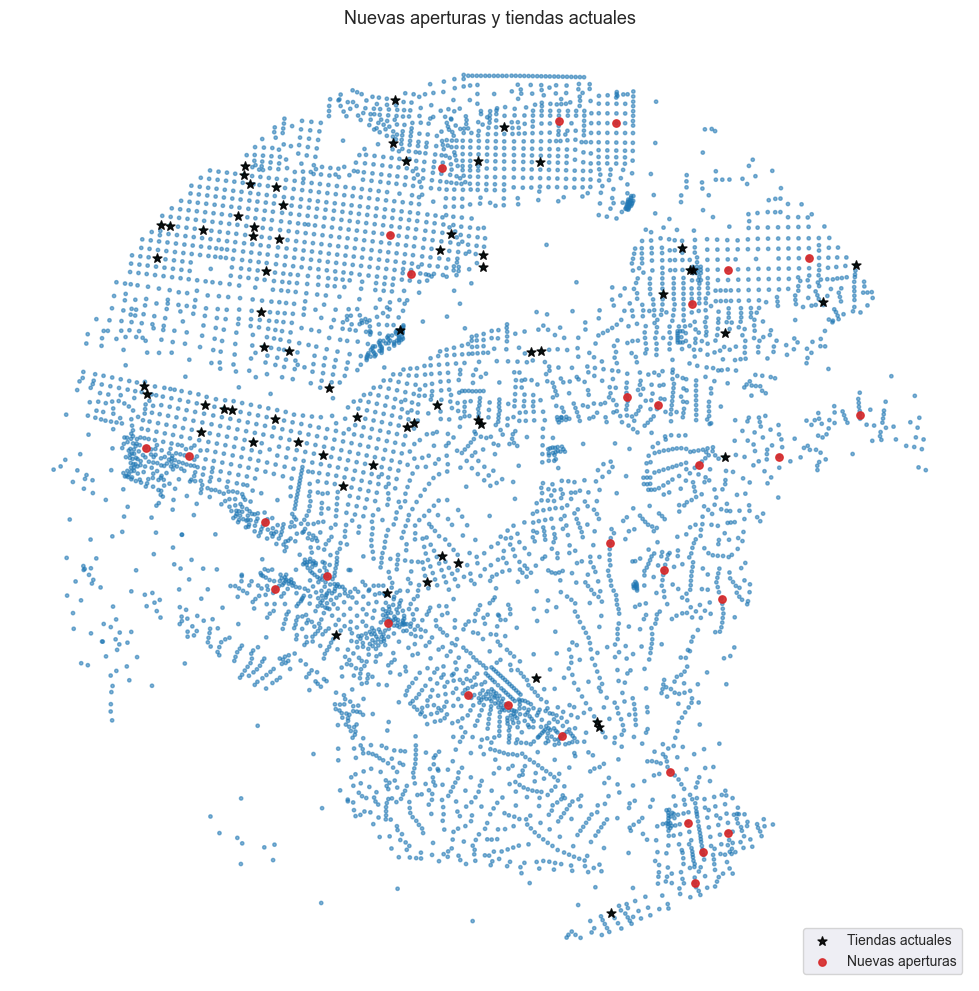

Figura guardada en: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\mapa_aperturas_global.png


In [85]:

# Plot: nuevas aperturas + tiendas actuales
CSV_BASE = PROCESSED_DIR / 'condensado.csv'
CSV_OPEN = RESULTS_DIR / 'aperturas_global.csv'
OUT_PNG = FIG_DIR / 'mapa_aperturas_global.png'

df_base = pd.read_csv(CSV_BASE)
opens = pd.read_csv(CSV_OPEN)

gdf_base_pts = gpd.GeoDataFrame(
    df_base.copy(),
    geometry=gpd.points_from_xy(df_base['lon'], df_base['lat']),
    crs='EPSG:4326',
)

gdf_ox = gdf_base_pts.loc[gdf_base_pts['oxxo_presente'] == 1, ['oxxo_presente', 'geometry']].copy()

if len(opens) > 0:
    gdf_open = gpd.GeoDataFrame(
        opens.copy(),
        geometry=gpd.points_from_xy(opens['lon'], opens['lat']),
        crs='EPSG:4326',
    )
else:
    gdf_open = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))

gdf_base_pts.plot(
    ax=ax,
    column='oxxo_presente' if 'oxxo_presente' in gdf_base_pts.columns else None,
    categorical='oxxo_presente' in gdf_base_pts.columns,
    legend='oxxo_presente' in gdf_base_pts.columns,
    markersize=6,
    alpha=0.55,
)

if len(gdf_ox) > 0:
    gdf_ox.plot(ax=ax, color='k', marker='*', markersize=45, alpha=0.9, label='Tiendas actuales')

if len(gdf_open) > 0:
    gdf_open.plot(ax=ax, color='tab:red', marker='o', markersize=28, alpha=0.9, label='Nuevas aperturas')

ax.set_title('Nuevas aperturas y tiendas actuales', fontsize=13)
ax.set_axis_off()
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en:', OUT_PNG)


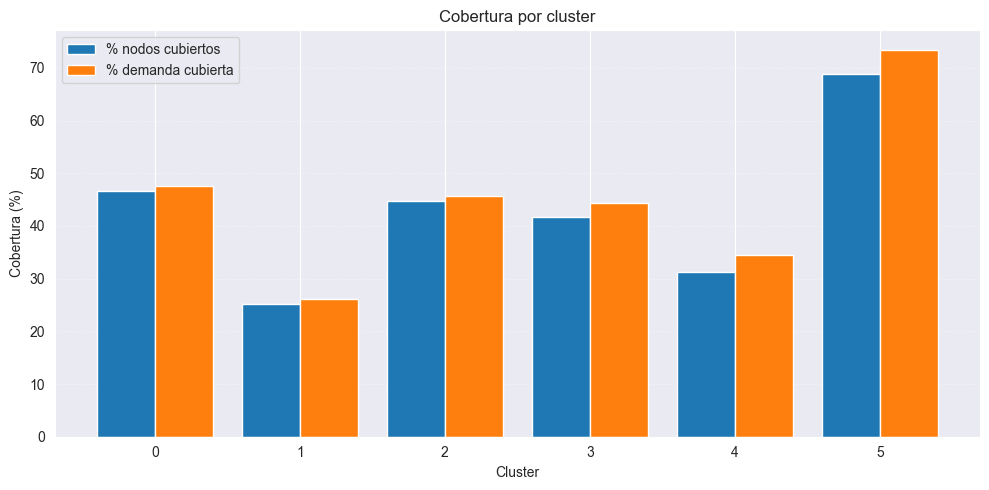

Figura guardada en: C:\Users\anduj\Documents\tecnologico_de_monterrey\research\facility_location\outputs\figures\benchmark_cobertura_por_cluster.png


In [86]:

# Benchmark: cobertura por cluster (no ponderado y ponderado por demanda)
METRICS = RESULTS_DIR / 'metrics_por_cluster.csv'
ASIG = RESULTS_DIR / 'asignaciones_global.csv'

m = pd.read_csv(METRICS).sort_values('cluster')
a = pd.read_csv(ASIG)

g = (
    a.groupby('cluster_i')
    .apply(lambda g: g.loc[g['uncovered'] == 0, 'w_i'].sum() / max(g['w_i'].sum(), 1e-9))
    .rename('pct_cov_weighted')
    .reset_index()
)

df_plot_cov = (
    m[['cluster', 'pct_covered']]
    .merge(g.rename(columns={'cluster_i': 'cluster'}), on='cluster', how='left')
)

x = df_plot_cov['cluster'].astype(int)
w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - w / 2, 100 * df_plot_cov['pct_covered'], width=w, label='% nodos cubiertos')
ax.bar(x + w / 2, 100 * df_plot_cov['pct_cov_weighted'], width=w, label='% demanda cubierta')

ax.set_xticks(x)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cobertura (%)')
ax.set_title('Cobertura por cluster')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
out = FIG_DIR / 'benchmark_cobertura_por_cluster.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en:', out)
